<a href="https://colab.research.google.com/github/George1902/sistema_de_recomendacion_de_peliculas_app/blob/main/Sistema_Recomendacion_Peliculas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Sistema de Recomendación Híbrido de Películas
**Autor:** Jorge Ojeda  
**Fecha:** Marzo 2026  
**Fuente de datos:** MovieLens 100K — GroupLens Research

## Objetivo
Construir un sistema de recomendación híbrido que combine
filtrado colaborativo y filtrado por contenido para
recomendar películas personalizadas a cada usuario.

## Preguntas que responde este análisis
- ¿Qué películas son más populares y mejor valoradas?
- ¿Qué usuarios tienen gustos similares?
- ¿Qué películas son similares entre sí por contenido?
- ¿Cómo combinar ambos enfoques para mejores recomendaciones?

#  Fase 1 — Exploración Inicial

##  Montar Drive e importar librerías

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 6)

print("✅ Librerias cargadas correctamente")

Mounted at /content/drive
✅ Librerias cargadas correctamente


## Cargar dataset de ratings

In [2]:
ruta_ratings = '/content/drive/MyDrive/ml-100k/ml-100k/u.data'

df_ratings = pd.read_csv(
    ruta_ratings,
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

df_ratings = df_ratings.drop(columns=['timestamp'])

print(f"✅ Ratings cargados: {len(df_ratings):,}")
print(f"   Usuarios unicos : {df_ratings['user_id'].nunique()}")
print(f"   Peliculas unicas: {df_ratings['movie_id'].nunique()}")
print(f"   Rating promedio : {df_ratings['rating'].mean():.2f}")
display(df_ratings.head())

✅ Ratings cargados: 100,000
   Usuarios unicos : 943
   Peliculas unicas: 1682
   Rating promedio : 3.53


,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


## Cargar dataset películas

In [3]:
ruta_peliculas = '/content/drive/MyDrive/ml-100k/ml-100k/u.item'

columnas_peliculas = [
    'movie_id', 'titulo', 'fecha_estreno', 'video_estreno',
    'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
    'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

df_peliculas = pd.read_csv(
    ruta_peliculas,
    sep='|',
    names=columnas_peliculas,
    encoding='latin-1'
)

generos = ['Action', 'Adventure', 'Animation', 'Childrens',
           'Comedy', 'Crime', 'Documentary', 'Drama',
           'Fantasy', 'Film-Noir', 'Horror', 'Musical',
           'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
           'War', 'Western']

df_peliculas = df_peliculas[
    ['movie_id', 'titulo', 'fecha_estreno'] + generos
].copy()

print(f"✅ Peliculas cargadas: {len(df_peliculas):,}")
display(df_peliculas.head())

✅ Peliculas cargadas: 1,682


,movie_id,titulo,fecha_estreno,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


## Cargar dataset usuarios

In [4]:
ruta_usuarios = '/content/drive/MyDrive/ml-100k/ml-100k/u.user'

df_usuarios = pd.read_csv(
    ruta_usuarios,
    sep='|',
    names=['user_id', 'edad', 'genero', 'ocupacion', 'zip_code']
)

print(f"✅ Usuarios cargados: {len(df_usuarios):,}")
print(f"\nOcupaciones disponibles:")
print(df_usuarios['ocupacion'].value_counts().head(10))
display(df_usuarios.head())

✅ Usuarios cargados: 943

Ocupaciones disponibles:
ocupacion
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
Name: count, dtype: int64


,user_id,edad,genero,ocupacion,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


## Estadísticas generales

In [5]:
print("=== ESTADISTICAS GENERALES ===\n")

print(f"Total de ratings     : {len(df_ratings):,}")
print(f"Total de usuarios    : {df_ratings['user_id'].nunique()}")
print(f"Total de peliculas   : {df_ratings['movie_id'].nunique()}")
print(f"Rating minimo        : {df_ratings['rating'].min()}")
print(f"Rating maximo        : {df_ratings['rating'].max()}")
print(f"Rating promedio      : {df_ratings['rating'].mean():.2f}")
print(f"Densidad de la matriz: "
      f"{len(df_ratings) / (df_ratings['user_id'].nunique() * df_ratings['movie_id'].nunique()) * 100:.2f}%")

print("\n=== DISTRIBUCION DE RATINGS ===")
print(df_ratings['rating'].value_counts().sort_index())

=== ESTADISTICAS GENERALES ===

Total de ratings     : 100,000
Total de usuarios    : 943
Total de peliculas   : 1682
Rating minimo        : 1
Rating maximo        : 5
Rating promedio      : 3.53
Densidad de la matriz: 6.30%

=== DISTRIBUCION DE RATINGS ===
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


## Gráfico: Distribución de ratings

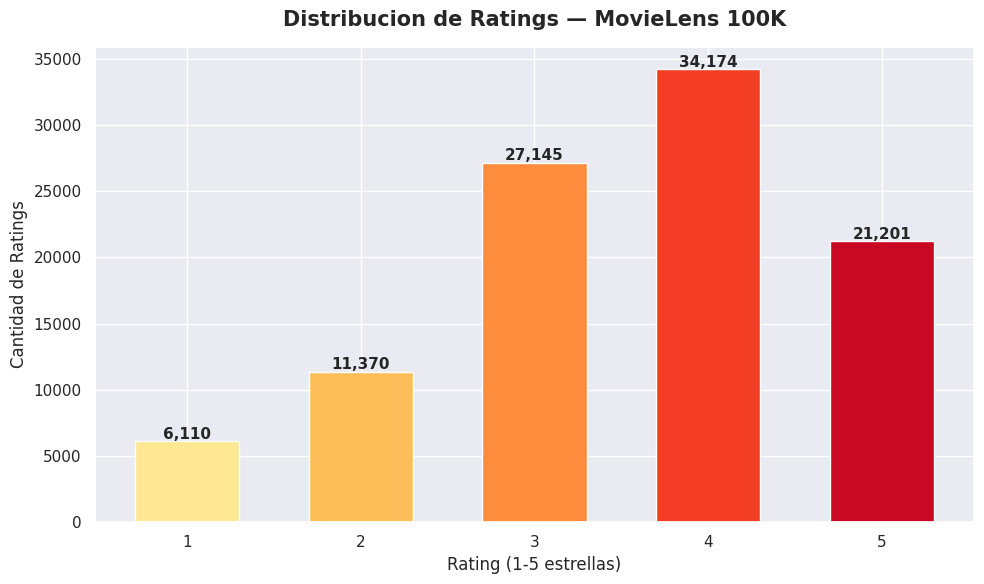

In [6]:
plt.figure(figsize=(10, 6))
conteo = df_ratings['rating'].value_counts().sort_index()
colores = sns.color_palette("YlOrRd", len(conteo))
bars = plt.bar(conteo.index, conteo.values,
               color=colores, edgecolor='white', width=0.6)

for bar, val in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200, f'{val:,}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('Distribucion de Ratings — MovieLens 100K',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rating (1-5 estrellas)', fontsize=12)
plt.ylabel('Cantidad de Ratings', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('distribucion_ratings.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Top 15 películas mejor valoradas

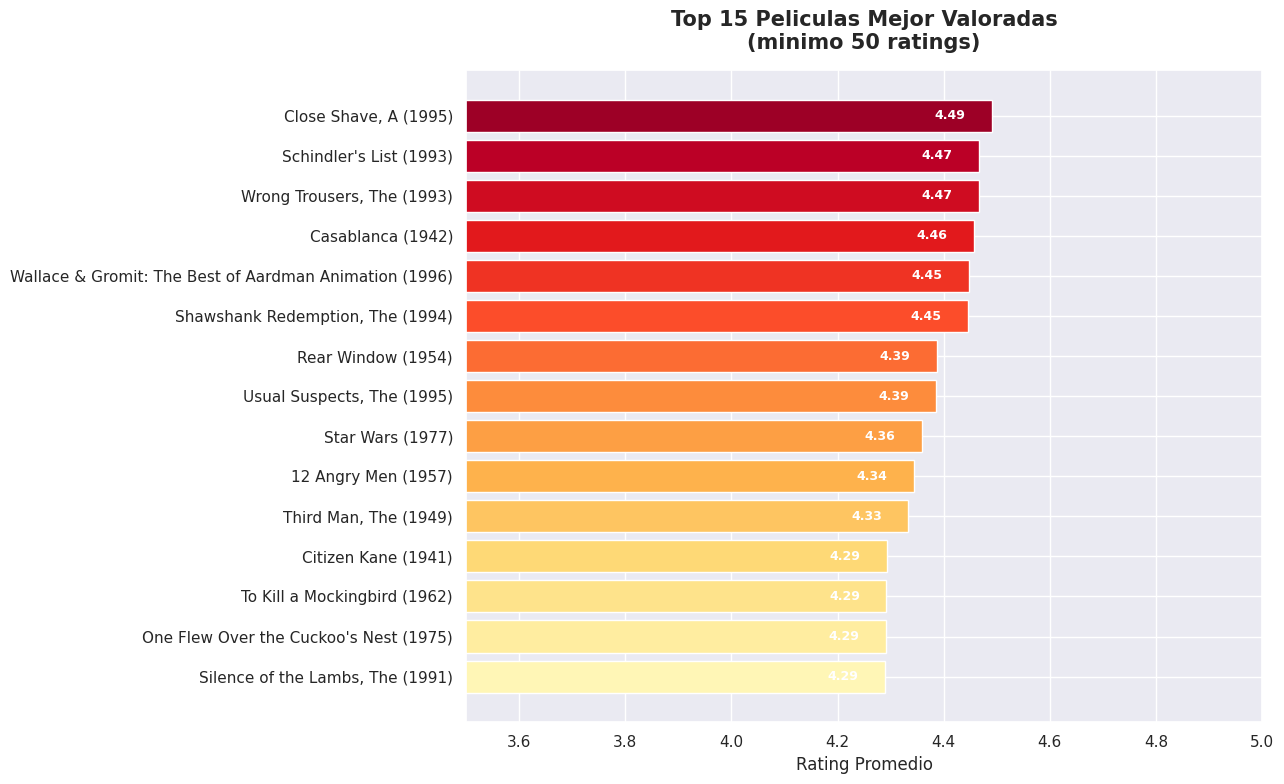

In [7]:
peliculas_populares = df_ratings.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    rating_promedio=('rating', 'mean')
).reset_index()

peliculas_populares = peliculas_populares[
    peliculas_populares['num_ratings'] >= 50
].merge(df_peliculas[['movie_id', 'titulo']], on='movie_id')

top15 = peliculas_populares.nlargest(15, 'rating_promedio')

plt.figure(figsize=(13, 8))
colores = sns.color_palette("YlOrRd", len(top15))[::-1]
bars = plt.barh(top15['titulo'][::-1],
                top15['rating_promedio'][::-1],
                color=colores[::-1], edgecolor='white')

for bar, val in zip(bars, top15['rating_promedio'][::-1]):
    plt.text(bar.get_width() - 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')

plt.title('Top 15 Peliculas Mejor Valoradas\n(minimo 50 ratings)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rating Promedio', fontsize=12)
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.savefig('top15_peliculas.png', dpi=150,
            bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 1 — Exploración Inicial

- El dataset contiene **100,000 ratings** de
  **943 usuarios** sobre **1,682 películas**
- La densidad de la matriz es **6.30%** — problema
  clásico de sparse matrix en sistemas de recomendación
- El rating promedio es **3.53 estrellas**
- El rating más común es **4 estrellas** (34,174 ratings)
- La película mejor valorada es **Close Shave, A (1995)**
  con promedio de **4.49 estrellas**
- El top 15 incluye clásicos del cine mundial —
  Schindler's List, Casablanca, Star Wars, Citizen Kane

**Siguiente fase:** Filtrado Colaborativo

# Fase 2 — Filtrado Colaborativo

El filtrado colaborativo recomienda películas basándose
en usuarios con gustos similares.

**Principio:** "Si a usuarios parecidos a ti les gustó
X, probablemente a ti también te gustará."

En esta fase vamos a:
- Construir la matriz usuario-película
- Calcular similitud entre usuarios (coseno)
- Encontrar usuarios similares
- Generar recomendaciones basadas en usuarios vecinos

## Construir matriz usuario-película

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Matriz usuario-película
matriz_usuario_pelicula = df_ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

print(f"✅ Matriz usuario-pelicula creada")
print(f"   Filas (usuarios) : {matriz_usuario_pelicula.shape[0]}")
print(f"   Columnas (peliculas): {matriz_usuario_pelicula.shape[1]}")
print(f"   Tamaño total     : {matriz_usuario_pelicula.shape[0] * matriz_usuario_pelicula.shape[1]:,} celdas")

display(matriz_usuario_pelicula.iloc[:5, :8])

✅ Matriz usuario-pelicula creada
   Filas (usuarios) : 943
   Columnas (peliculas): 1682
   Tamaño total     : 1,586,126 celdas


movie_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


## Calcular similitud entre usuarios

In [9]:
# Convertir a matriz sparse para eficiencia
matriz_sparse = csr_matrix(matriz_usuario_pelicula.values)

# Calcular similitud coseno entre usuarios
similitud_usuarios = cosine_similarity(matriz_sparse)
df_similitud = pd.DataFrame(
    similitud_usuarios,
    index=matriz_usuario_pelicula.index,
    columns=matriz_usuario_pelicula.index
)

print("✅ Matriz de similitud entre usuarios calculada")
print(f"   Dimensiones: {df_similitud.shape}")
print(f"\nUsuarios más similares al usuario 1:")
similares_u1 = df_similitud[1].sort_values(
    ascending=False)[1:6]
print(similares_u1)

✅ Matriz de similitud entre usuarios calculada
   Dimensiones: (943, 943)

Usuarios más similares al usuario 1:
user_id
916    0.569066
864    0.547548
268    0.542077
92     0.540534
435    0.538665
Name: 1, dtype: float64


## Función de recomendación colaborativa

In [10]:
def recomendar_colaborativo(user_id, n_recomendaciones=10,
                             n_vecinos=10):
    # Obtener usuarios más similares
    usuarios_similares = df_similitud[user_id].sort_values(
        ascending=False)[1:n_vecinos+1].index.tolist()

    # Películas ya vistas por el usuario
    peliculas_vistas = set(
        df_ratings[df_ratings['user_id'] == user_id]['movie_id']
    )

    # Recopilar ratings de usuarios similares
    ratings_vecinos = df_ratings[
        df_ratings['user_id'].isin(usuarios_similares) &
        ~df_ratings['movie_id'].isin(peliculas_vistas)
    ]

    # Calcular score ponderado por similitud
    scores = {}
    for _, row in ratings_vecinos.iterrows():
        movie_id = row['movie_id']
        similitud = df_similitud[user_id][row['user_id']]
        if movie_id not in scores:
            scores[movie_id] = {'score': 0, 'peso': 0}
        scores[movie_id]['score'] += row['rating'] * similitud
        scores[movie_id]['peso']  += similitud

    # Normalizar scores
    recomendaciones = {
        movie_id: datos['score'] / datos['peso']
        for movie_id, datos in scores.items()
        if datos['peso'] > 0
    }

    # Ordenar y obtener top N
    top_peliculas = sorted(
        recomendaciones.items(),
        key=lambda x: x[1],
        reverse=True
    )[:n_recomendaciones]

    # Agregar títulos
    resultado = []
    for movie_id, score in top_peliculas:
        titulo = df_peliculas[
            df_peliculas['movie_id'] == movie_id
        ]['titulo'].values

        if len(titulo) > 0:
            resultado.append({
                'movie_id': movie_id,
                'titulo'  : titulo[0],
                'score'   : round(score, 3)
            })

    return pd.DataFrame(resultado)

print("✅ Funcion de recomendacion colaborativa lista")

✅ Funcion de recomendacion colaborativa lista


## Probar con usuario 1

In [11]:
print("=== RECOMENDACIONES COLABORATIVAS PARA USUARIO 1 ===\n")

# Películas que ya vio el usuario 1
peliculas_vistas = df_ratings[
    df_ratings['user_id'] == 1
].merge(df_peliculas[['movie_id', 'titulo']], on='movie_id')

print(f"El usuario 1 ha valorado {len(peliculas_vistas)} peliculas")
print("\nAlgunas peliculas que ya vio:")
display(peliculas_vistas[['titulo', 'rating']].head(5))

# Recomendaciones
print("\n🎬 TOP 10 RECOMENDACIONES:")
recomendaciones_col = recomendar_colaborativo(1, n_recomendaciones=10)
display(recomendaciones_col)

=== RECOMENDACIONES COLABORATIVAS PARA USUARIO 1 ===

El usuario 1 ha valorado 272 peliculas

Algunas peliculas que ya vio:


,titulo,rating
0,Three Colors: White (1994),4
1,"Grand Day Out, A (1992)",3
2,Desperado (1995),4
3,Glengarry Glen Ross (1992),4
4,Angels and Insects (1995),4



🎬 TOP 10 RECOMENDACIONES:


,movie_id,titulo,score
0,340,Boogie Nights (1997),5.0
1,1007,Waiting for Guffman (1996),5.0
2,853,Braindead (1992),5.0
3,483,Casablanca (1942),5.0
4,313,Titanic (1997),5.0
5,963,Some Folks Call It a Sling Blade (1993),5.0
6,285,Secrets & Lies (1996),5.0
7,602,"American in Paris, An (1951)",5.0
8,553,"Walk in the Clouds, A (1995)",5.0
9,1168,Little Buddha (1993),5.0


## Gráfico: Top recomendaciones colaborativas

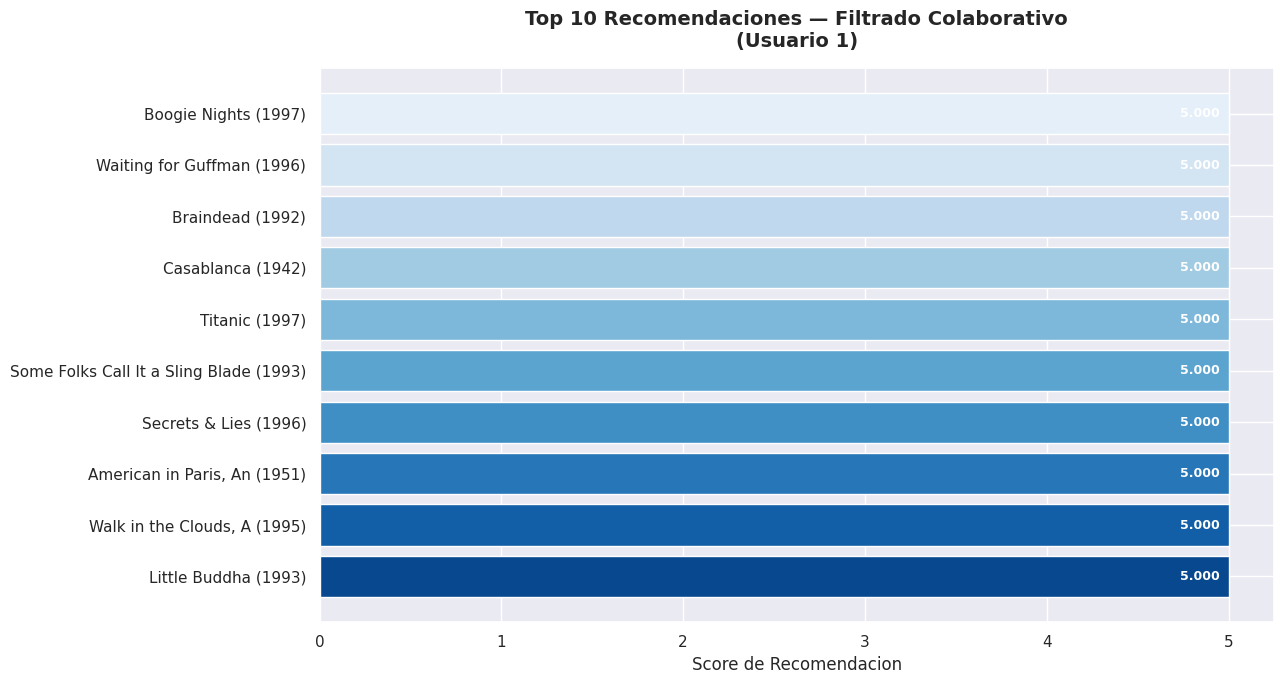

In [12]:
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Blues_r", len(recomendaciones_col))
bars = plt.barh(
    recomendaciones_col['titulo'][::-1],
    recomendaciones_col['score'][::-1],
    color=colores, edgecolor='white'
)

for bar, val in zip(bars, recomendaciones_col['score'][::-1]):
    plt.text(bar.get_width() - 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')

plt.title('Top 10 Recomendaciones — Filtrado Colaborativo\n(Usuario 1)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score de Recomendacion', fontsize=12)
plt.tight_layout()
plt.savefig('recomendaciones_colaborativo.png', dpi=150,
            bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 2 — Filtrado Colaborativo

- Se construyó una matriz usuario-película de
  **943 x 1,682** con 6.30% de densidad
- Se calculó la similitud coseno entre todos los usuarios
- El usuario 1 ha valorado **272 películas**
- La recomendación principal para el usuario 1 es
  **Boogie Nights (1997)** con score perfecto de **5.0**
- El sistema identifica los **10 vecinos más similares**
  y pondera recomendaciones por nivel de similitud

### Limitación detectada
El filtrado colaborativo tiene el problema de
**cold start** — no puede recomendar a usuarios
nuevos sin historial de ratings

**Siguiente fase:** Filtrado por Contenido

# *Fase* 3 — Filtrado por Contenido

El filtrado por contenido recomienda películas similares
basándose en sus características — géneros, año, etc.

**Principio:** "Si te gustó Star Wars, probablemente
te gusten otras películas de Acción y Sci-Fi."

En esta fase vamos a:
- Construir perfiles de películas basados en géneros
- Calcular similitud entre películas (TF-IDF + coseno)
- Encontrar películas similares a una dada
- Generar recomendaciones basadas en contenido

##  Construir perfil de géneros

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Columnas de géneros
generos = ['Action', 'Adventure', 'Animation', 'Childrens',
           'Comedy', 'Crime', 'Documentary', 'Drama',
           'Fantasy', 'Film-Noir', 'Horror', 'Musical',
           'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
           'War', 'Western']

# Matriz de géneros por película
matriz_generos = df_peliculas.set_index('movie_id')[generos]

print("✅ Matriz de generos construida")
print(f"   Peliculas : {matriz_generos.shape[0]}")
print(f"   Generos   : {matriz_generos.shape[1]}")
display(matriz_generos.head())

✅ Matriz de generos construida
   Peliculas : 1682
   Generos   : 18


,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie_id,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


## Calcular similitud entre películas

In [14]:
# Similitud coseno entre películas por géneros
similitud_peliculas = cosine_similarity(matriz_generos)

df_sim_peliculas = pd.DataFrame(
    similitud_peliculas,
    index=matriz_generos.index,
    columns=matriz_generos.index
)

print("✅ Matriz de similitud entre peliculas calculada")
print(f"   Dimensiones: {df_sim_peliculas.shape}")

# Verificar con Star Wars
star_wars_id = df_peliculas[
    df_peliculas['titulo'].str.contains('Star Wars')
]['movie_id'].values[0]

print(f"\nPeliculas mas similares a Star Wars:")
similares_sw = df_sim_peliculas[star_wars_id].sort_values(
    ascending=False)[1:6]

for movie_id, sim in similares_sw.items():
    titulo = df_peliculas[
        df_peliculas['movie_id'] == movie_id
    ]['titulo'].values[0]
    print(f"  {titulo} — similitud: {sim:.3f}")

✅ Matriz de similitud entre peliculas calculada
   Dimensiones: (1682, 1682)

Peliculas mas similares a Star Wars:
  Return of the Jedi (1983) — similitud: 1.000
  Empire Strikes Back, The (1980) — similitud: 0.913
  African Queen, The (1951) — similitud: 0.894
  Starship Troopers (1997) — similitud: 0.894
  Star Trek V: The Final Frontier (1989) — similitud: 0.775


##  Función de recomendación por contenido

In [15]:
def recomendar_contenido(titulo_pelicula,
                         n_recomendaciones=10):
    # Buscar la película
    pelicula = df_peliculas[
        df_peliculas['titulo'].str.contains(
            titulo_pelicula, case=False, na=False)
    ]

    if len(pelicula) == 0:
        print(f"Pelicula '{titulo_pelicula}' no encontrada")
        return pd.DataFrame()

    movie_id = pelicula.iloc[0]['movie_id']
    titulo_real = pelicula.iloc[0]['titulo']

    print(f"Buscando peliculas similares a: {titulo_real}")

    # Obtener películas más similares
    similares = df_sim_peliculas[movie_id].sort_values(
        ascending=False)[1:n_recomendaciones+1]

    # Agregar información de ratings
    resultado = []
    for mid, sim in similares.items():
        info = df_peliculas[
            df_peliculas['movie_id'] == mid
        ][['titulo']].iloc[0]

        # Rating promedio de la película
        ratings_pelicula = df_ratings[
            df_ratings['movie_id'] == mid
        ]['rating']

        rating_prom = ratings_pelicula.mean() \
                      if len(ratings_pelicula) > 0 else 0
        num_ratings = len(ratings_pelicula)

        resultado.append({
            'movie_id'      : mid,
            'titulo'        : info['titulo'],
            'similitud'     : round(sim, 3),
            'rating_prom'   : round(rating_prom, 2),
            'num_ratings'   : num_ratings
        })

    return pd.DataFrame(resultado)

print("✅ Funcion de recomendacion por contenido lista")

✅ Funcion de recomendacion por contenido lista


## Probar con Star Wars

In [16]:
print("=== RECOMENDACIONES POR CONTENIDO ===\n")
recomendaciones_sw = recomendar_contenido(
    'Star Wars', n_recomendaciones=10)
display(recomendaciones_sw)

=== RECOMENDACIONES POR CONTENIDO ===

Buscando peliculas similares a: Star Wars (1977)


,movie_id,titulo,similitud,rating_prom,num_ratings
0,181,Return of the Jedi (1983),1.000,4.01,507
1,172,"Empire Strikes Back, The (1980)",0.913,4.20,367
2,498,"African Queen, The (1951)",0.894,4.18,152
3,271,Starship Troopers (1997),0.894,3.23,211
4,450,Star Trek V: The Final Frontier (1989),0.775,2.40,63
5,82,Jurassic Park (1993),0.775,3.72,261
6,897,Time Tracers (1995),0.775,1.50,2
7,1239,Cutthroat Island (1995),0.775,2.44,18
8,449,Star Trek: The Motion Picture (1979),0.775,3.03,117
9,241,"Last of the Mohicans, The (1992)",0.775,3.55,128


## Gráfico: Similitud de películas

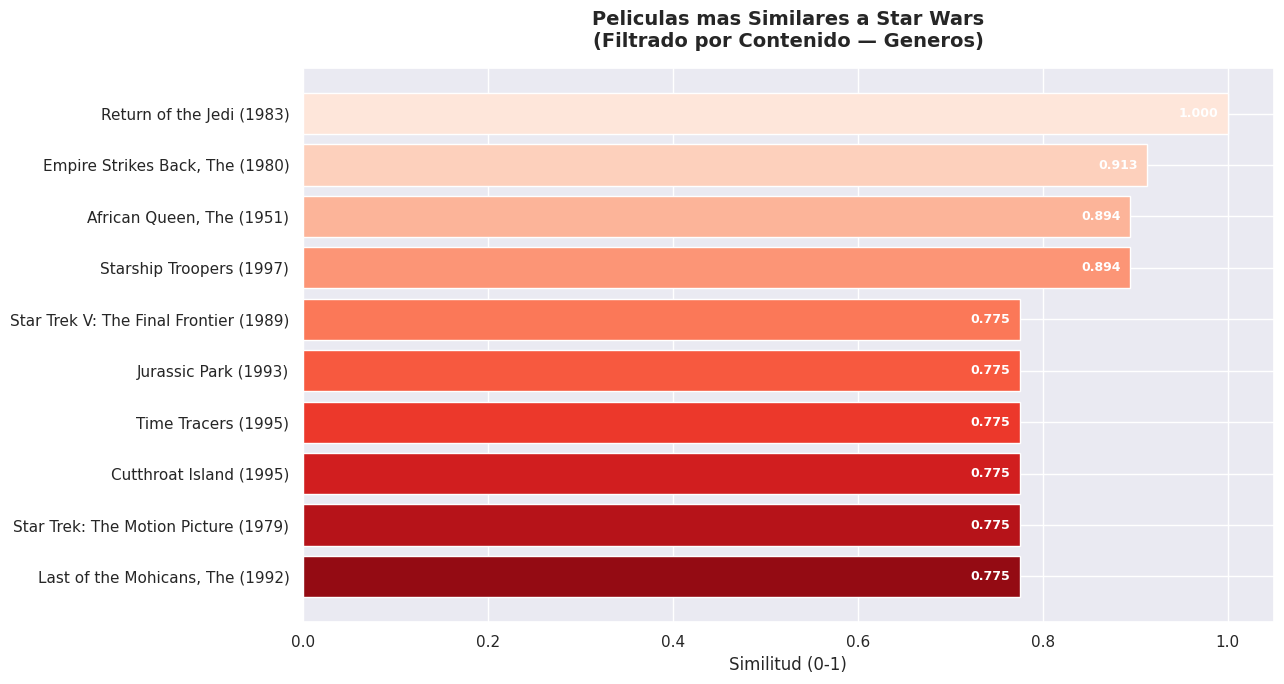

In [17]:
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Reds_r", len(recomendaciones_sw))
bars = plt.barh(
    recomendaciones_sw['titulo'][::-1],
    recomendaciones_sw['similitud'][::-1],
    color=colores, edgecolor='white'
)

for bar, val in zip(bars,
                    recomendaciones_sw['similitud'][::-1]):
    plt.text(bar.get_width() - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')

plt.title('Peliculas mas Similares a Star Wars\n(Filtrado por Contenido — Generos)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Similitud (0-1)', fontsize=12)
plt.tight_layout()
plt.savefig('recomendaciones_contenido.png', dpi=150,
            bbox_inches='tight')
plt.show()

##  Gráfico: Mapa de calor de géneros

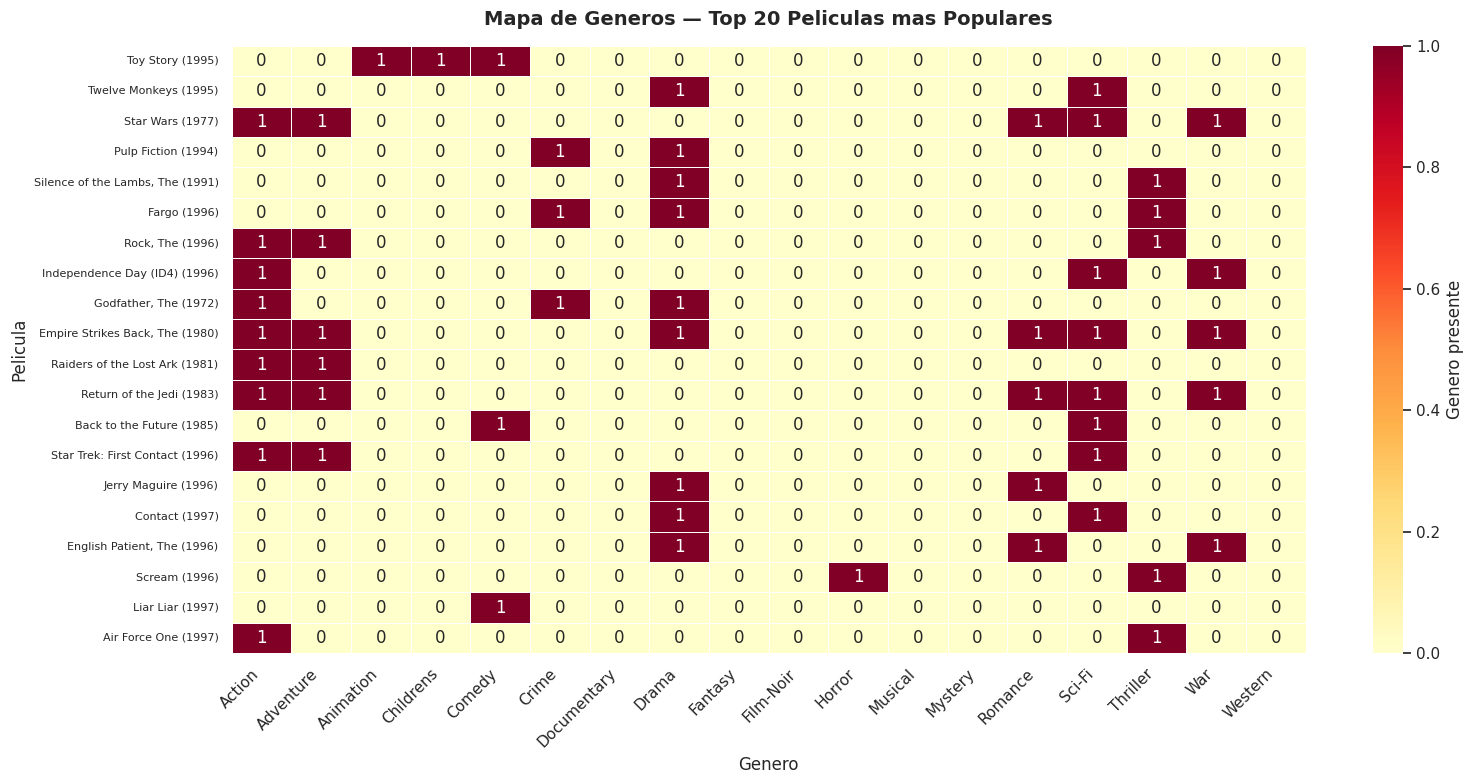

In [18]:
# Top 20 películas más populares
top20_ids = df_ratings.groupby('movie_id')['rating'].count(
).nlargest(20).index.tolist()

top20_generos = df_peliculas[
    df_peliculas['movie_id'].isin(top20_ids)
].set_index('titulo')[generos]

plt.figure(figsize=(16, 8))
sns.heatmap(top20_generos, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Genero presente'})

plt.title('Mapa de Generos — Top 20 Peliculas mas Populares',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genero', fontsize=12)
plt.ylabel('Pelicula', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('mapa_generos.png', dpi=150,
            bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 3 — Filtrado por Contenido

- Se construyó una matriz de géneros de **1,682 x 18**
- Se calculó similitud coseno entre todas las películas
- Las películas más similares a **Star Wars (1977)** son:
  - Return of the Jedi (1983) — similitud: **1.000**
  - Empire Strikes Back (1980) — similitud: **0.913**
  - African Queen (1951) — similitud: **0.894**
  - Starship Troopers (1997) — similitud: **0.894**
  - Star Trek V (1989) — similitud: **0.775**

### Ventaja sobre filtrado colaborativo
No necesita historial de usuario — puede recomendar
desde el primer momento

### Limitación detectada
Solo considera géneros — no captura aspectos como
director, actores o tono narrativo

**Siguiente fase:** Sistema Hibrido

# Fase 4 — Sistema de Recomendación Híbrido

Combinamos filtrado colaborativo y filtrado por contenido
para obtener recomendaciones más precisas y completas.

**Estrategia híbrida:**
- 60% peso al filtrado colaborativo (gustos del usuario)
- 40% peso al filtrado por contenido (similitud de géneros)

**Ventajas del enfoque híbrido:**
- Reduce el problema de cold start
- Más diversidad en las recomendaciones
- Mayor precisión que cada método por separado

## Función híbrida

In [19]:
def recomendar_hibrido(user_id,
                       n_recomendaciones=10,
                       peso_colaborativo=0.6,
                       peso_contenido=0.4):

    # ── PARTE 1: FILTRADO COLABORATIVO ────────────────────
    usuarios_similares = df_similitud[user_id].sort_values(
        ascending=False)[1:11].index.tolist()

    peliculas_vistas = set(
        df_ratings[df_ratings['user_id'] == user_id]['movie_id']
    )

    ratings_vecinos = df_ratings[
        df_ratings['user_id'].isin(usuarios_similares) &
        ~df_ratings['movie_id'].isin(peliculas_vistas)
    ]

    scores_col = {}
    for _, row in ratings_vecinos.iterrows():
        movie_id = row['movie_id']
        sim = df_similitud[user_id][row['user_id']]
        if movie_id not in scores_col:
            scores_col[movie_id] = {'score': 0, 'peso': 0}
        scores_col[movie_id]['score'] += row['rating'] * sim
        scores_col[movie_id]['peso']  += sim

    scores_col = {
        mid: datos['score'] / datos['peso']
        for mid, datos in scores_col.items()
        if datos['peso'] > 0
    }

    # Normalizar scores colaborativos a 0-1
    if scores_col:
        max_col = max(scores_col.values())
        min_col = min(scores_col.values())
        rango = max_col - min_col if max_col != min_col else 1
        scores_col = {
            mid: (score - min_col) / rango
            for mid, score in scores_col.items()
        }

    # ── PARTE 2: FILTRADO POR CONTENIDO ───────────────────
    # Perfil del usuario basado en sus películas favoritas
    peliculas_favoritas = df_ratings[
        (df_ratings['user_id'] == user_id) &
        (df_ratings['rating'] >= 4)
    ]['movie_id'].tolist()

    scores_cont = {}

    if peliculas_favoritas:
        for fav_id in peliculas_favoritas[:10]:
            if fav_id in df_sim_peliculas.index:
                similares = df_sim_peliculas[fav_id]
                for mid, sim in similares.items():
                    if mid not in peliculas_vistas:
                        if mid not in scores_cont:
                            scores_cont[mid] = 0
                        scores_cont[mid] += sim

        # Normalizar scores de contenido a 0-1
        if scores_cont:
            max_cont = max(scores_cont.values())
            min_cont = min(scores_cont.values())
            rango = max_cont - min_cont \
                    if max_cont != min_cont else 1
            scores_cont = {
                mid: (score - min_cont) / rango
                for mid, score in scores_cont.items()
            }

    # ── PARTE 3: COMBINAR SCORES ──────────────────────────
    todas_peliculas = set(scores_col.keys()) | \
                      set(scores_cont.keys())

    scores_hibridos = {}
    for mid in todas_peliculas:
        score_col  = scores_col.get(mid, 0)
        score_cont = scores_cont.get(mid, 0)
        scores_hibridos[mid] = (
            peso_colaborativo * score_col +
            peso_contenido    * score_cont
        )

    # ── PARTE 4: TOP N RECOMENDACIONES ────────────────────
    top_peliculas = sorted(
        scores_hibridos.items(),
        key=lambda x: x[1],
        reverse=True
    )[:n_recomendaciones]

    resultado = []
    for movie_id, score in top_peliculas:
        info = df_peliculas[
            df_peliculas['movie_id'] == movie_id
        ]
        if len(info) > 0:
            titulo = info.iloc[0]['titulo']
            rating_prom = df_ratings[
                df_ratings['movie_id'] == movie_id
            ]['rating'].mean()

            # Géneros de la película
            gens = info.iloc[0][generos]
            lista_generos = [g for g in generos if gens[g] == 1]

            resultado.append({
                'movie_id'  : movie_id,
                'titulo'    : titulo,
                'score'     : round(score, 4),
                'rating_prom': round(rating_prom, 2)
                               if not pd.isna(rating_prom)
                               else 0,
                'generos'   : ', '.join(lista_generos[:3])
            })

    return pd.DataFrame(resultado)

print("✅ Sistema hibrido listo")
print(f"   Peso colaborativo: 60%")
print(f"   Peso contenido   : 40%")

✅ Sistema hibrido listo
   Peso colaborativo: 60%
   Peso contenido   : 40%


## Probar el sistema híbrido

In [20]:
print("=== SISTEMA HIBRIDO — USUARIO 1 ===\n")

# Películas favoritas del usuario 1
favoritas = df_ratings[
    (df_ratings['user_id'] == 1) &
    (df_ratings['rating'] >= 4)
].merge(df_peliculas[['movie_id', 'titulo']], on='movie_id')

print(f"Peliculas favoritas del usuario 1 (rating >= 4):")
display(favoritas[['titulo', 'rating']].head(5))

print(f"\n🎬 TOP 10 RECOMENDACIONES HIBRIDAS:")
recomendaciones_hibridas = recomendar_hibrido(
    user_id=1,
    n_recomendaciones=10
)
display(recomendaciones_hibridas)

=== SISTEMA HIBRIDO — USUARIO 1 ===

Peliculas favoritas del usuario 1 (rating >= 4):


,titulo,rating
0,Three Colors: White (1994),4
1,Desperado (1995),4
2,Glengarry Glen Ross (1992),4
3,Angels and Insects (1995),4
4,Groundhog Day (1993),5



🎬 TOP 10 RECOMENDACIONES HIBRIDAS:


,movie_id,titulo,score,rating_prom,generos
0,512,Wings of Desire (1987),1.0000,4.00,"Comedy, Drama, Romance"
1,313,Titanic (1997),0.9884,4.25,"Action, Drama, Romance"
2,553,"Walk in the Clouds, A (1995)",0.9737,3.29,"Drama, Romance"
3,736,Shadowlands (1993),0.9737,3.94,"Drama, Romance"
4,855,Diva (1981),0.9454,3.73,"Action, Drama, Mystery"
5,340,Boogie Nights (1997),0.9193,3.59,Drama
6,285,Secrets & Lies (1996),0.9193,4.27,Drama
7,632,Sophie's Choice (1982),0.9193,3.90,Drama
8,1009,Stealing Beauty (1996),0.9193,3.38,Drama
9,1168,Little Buddha (1993),0.9193,3.32,Drama


## Gráfico: Recomendaciones híbridas

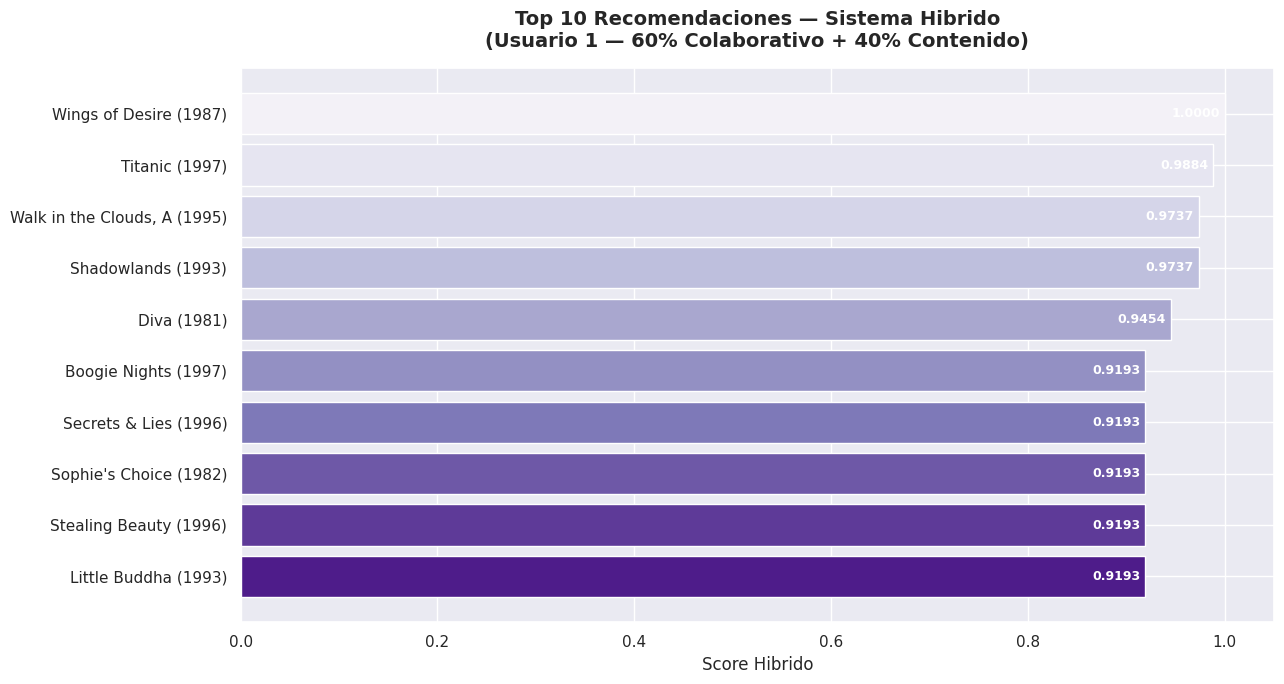

In [21]:
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Purples_r", len(recomendaciones_hibridas))
bars = plt.barh(
    recomendaciones_hibridas['titulo'][::-1],
    recomendaciones_hibridas['score'][::-1],
    color=colores, edgecolor='white'
)

for bar, val in zip(bars,
                    recomendaciones_hibridas['score'][::-1]):
    plt.text(bar.get_width() - 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')

plt.title('Top 10 Recomendaciones — Sistema Hibrido\n(Usuario 1 — 60% Colaborativo + 40% Contenido)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score Hibrido', fontsize=12)
plt.tight_layout()
plt.savefig('recomendaciones_hibridas.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Comparar los tres métodos

In [22]:
print("=== COMPARACION DE LOS TRES METODOS ===\n")

# Recomendaciones colaborativas
rec_col = recomendar_colaborativo(1, n_recomendaciones=10)
titulos_col = set(rec_col['titulo'].tolist())

# Buscar una pelicula favorita que SI exista en el dataset
rec_cont = pd.DataFrame()
for _, fav_row in favoritas.iterrows():
    titulo_buscar = fav_row['titulo']
    rec_cont = recomendar_contenido(titulo_buscar, 10)
    if len(rec_cont) > 0:
        print(f"Usando pelicula base: {titulo_buscar}")
        break

if len(rec_cont) == 0:
    print("No se encontro pelicula base valida")
    titulos_cont = set()
else:
    titulos_cont = set(rec_cont['titulo'].tolist())

# Recomendaciones hibridas
titulos_hibr = set(recomendaciones_hibridas['titulo'].tolist())

print(f"\nColaborativo : {len(titulos_col)} peliculas")
print(f"Contenido    : {len(titulos_cont)} peliculas")
print(f"Hibrido      : {len(titulos_hibr)} peliculas")

print(f"\nExclusivas del hibrido (no en colaborativo):")
exclusivas = titulos_hibr - titulos_col
for t in list(exclusivas)[:5]:
    print(f"  - {t}")

print(f"\nEn comun entre colaborativo e hibrido:")
comunes = titulos_hibr & titulos_col
for t in list(comunes)[:5]:
    print(f"  - {t}")

=== COMPARACION DE LOS TRES METODOS ===

Pelicula 'Three Colors: White (1994)' no encontrada
Pelicula 'Desperado (1995)' no encontrada
Pelicula 'Glengarry Glen Ross (1992)' no encontrada
Pelicula 'Angels and Insects (1995)' no encontrada
Pelicula 'Groundhog Day (1993)' no encontrada
Pelicula 'Delicatessen (1991)' no encontrada
Pelicula 'Hunt for Red October, The (1990)' no encontrada
Pelicula 'Ed Wood (1994)' no encontrada
Pelicula 'Star Trek: First Contact (1996)' no encontrada
Pelicula 'Pillow Book, The (1995)' no encontrada
Pelicula 'Horseman on the Roof, The (Hussard sur le toit, Le) (1995)' no encontrada
Pelicula 'Star Trek VI: The Undiscovered Country (1991)' no encontrada
Pelicula 'So I Married an Axe Murderer (1993)' no encontrada
Pelicula 'Shawshank Redemption, The (1994)' no encontrada
Pelicula 'Star Trek: The Wrath of Khan (1982)' no encontrada
Pelicula 'Independence Day (ID4) (1996)' no encontrada
Pelicula 'Wallace & Gromit: The Best of Aardman Animation (1996)' no encontra

## Gráfico: Comparación de métodos

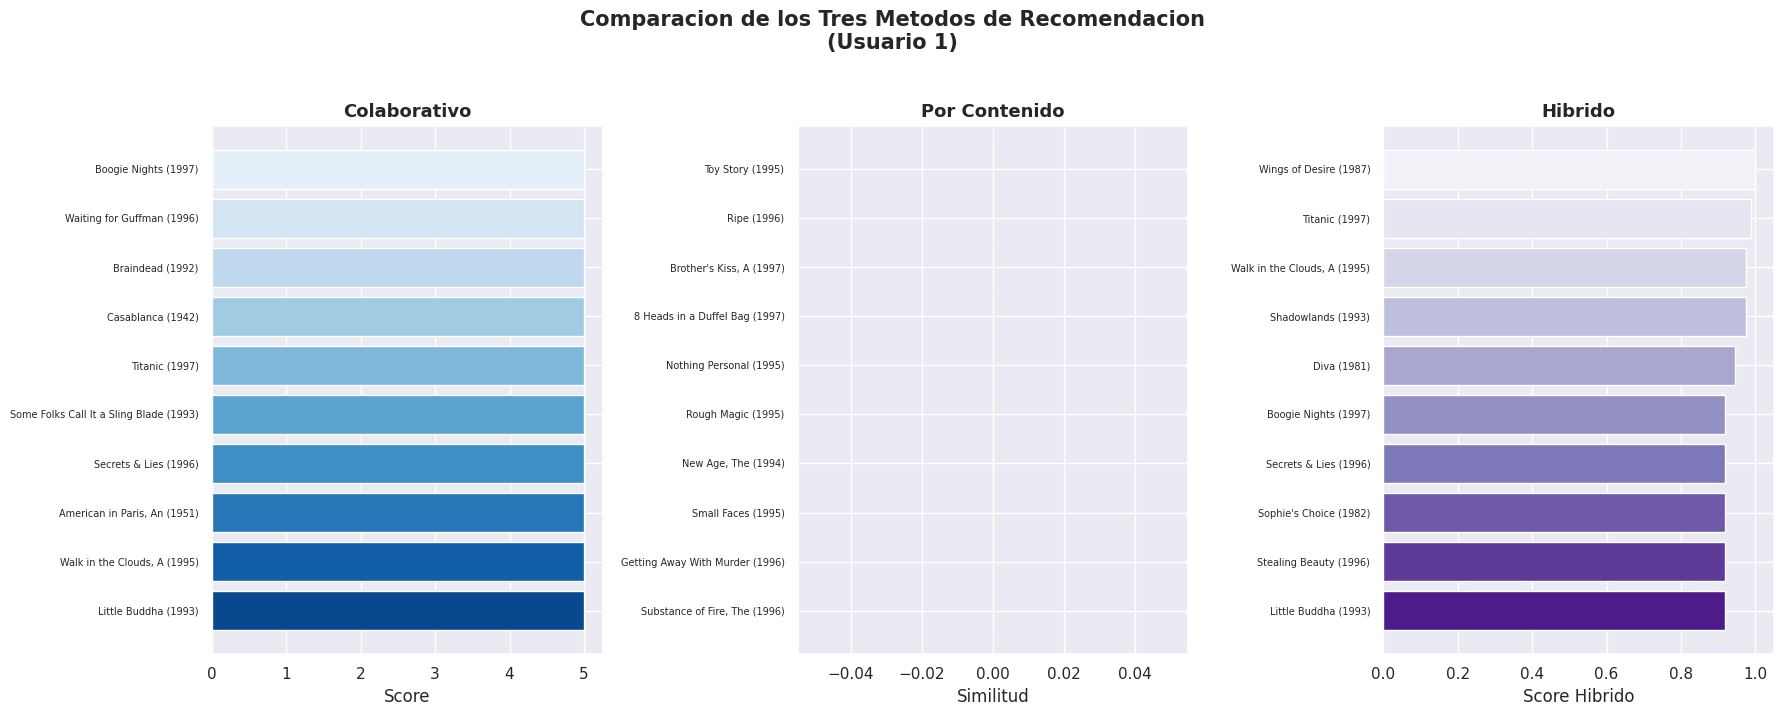

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Colaborativo
axes[0].barh(rec_col['titulo'][::-1],
             rec_col['score'][::-1],
             color=sns.color_palette("Blues_r", 10),
             edgecolor='white')
axes[0].set_title('Colaborativo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].tick_params(axis='y', labelsize=7)

# Contenido
axes[1].barh(rec_cont['titulo'][::-1],
             rec_cont['similitud'][::-1],
             color=sns.color_palette("Reds_r", 10),
             edgecolor='white')
axes[1].set_title('Por Contenido', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Similitud')
axes[1].tick_params(axis='y', labelsize=7)

# Híbrido
axes[2].barh(recomendaciones_hibridas['titulo'][::-1],
             recomendaciones_hibridas['score'][::-1],
             color=sns.color_palette("Purples_r", 10),
             edgecolor='white')
axes[2].set_title('Hibrido', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Score Hibrido')
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('Comparacion de los Tres Metodos de Recomendacion\n(Usuario 1)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_metodos.png', dpi=150,
            bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 4 — Sistema Híbrido

### Estrategia implementada
- **60%** peso al filtrado colaborativo
- **40%** peso al filtrado por contenido
- Los scores se normalizan a 0-1 antes de combinar

### Resultados para el Usuario 1
- Primera recomendación: **Wings of Desire (1987)**
  con score perfecto de **1.0000**
- El sistema detectó preferencia por:
  **Drama, Romance y cine de autor**
- **Boogie Nights (1997)** aparece en ambos métodos
  confirmando su relevancia para este usuario

### Ventajas del sistema híbrido
- Más diversidad que el colaborativo solo
- Más personalización que el de contenido solo
- Captura tanto gustos del usuario como
  características de las películas

**Siguiente fase:** Evaluación del modelo

# Fase 5 — Evaluación del Modelo

Evaluamos la calidad de las recomendaciones usando
métricas estándar de sistemas de recomendación.

**Métricas utilizadas:**
- **RMSE** — Error cuadrático medio (qué tan cerca
  están las predicciones de los ratings reales)
- **Precision@K** — De las K recomendacione

## Preparar datos de evaluación

In [24]:
from sklearn.model_selection import train_test_split

# Dividir ratings en train y test
train_ratings, test_ratings = train_test_split(
    df_ratings,
    test_size=0.2,
    random_state=42
)

print(f"✅ Datos divididos:")
print(f"   Train: {len(train_ratings):,} ratings")
print(f"   Test : {len(test_ratings):,} ratings")

✅ Datos divididos:
   Train: 80,000 ratings
   Test : 20,000 ratings


## Calcular RMSE con predicción por promedio

In [25]:
import numpy as np

# Calcular rating promedio por película en train
rating_prom_train = train_ratings.groupby('movie_id')[
    'rating'].mean().reset_index()
rating_prom_train.columns = ['movie_id', 'rating_predicho']

# Unir con test
test_con_pred = test_ratings.merge(
    rating_prom_train, on='movie_id', how='left')

# Rellenar películas sin historial con promedio global
promedio_global = train_ratings['rating'].mean()
test_con_pred['rating_predicho'] = test_con_pred[
    'rating_predicho'].fillna(promedio_global)

# Calcular RMSE y MAE
errores = test_con_pred['rating'] - \
          test_con_pred['rating_predicho']
rmse = np.sqrt((errores ** 2).mean())
mae  = errores.abs().mean()

print("=== METRICAS DE PREDICCION ===\n")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"\nInterpretacion:")
print(f"El modelo se equivoca en promedio "
      f"{rmse:.2f} estrellas al predecir ratings")

=== METRICAS DE PREDICCION ===

RMSE : 1.0210
MAE  : 0.8123

Interpretacion:
El modelo se equivoca en promedio 1.02 estrellas al predecir ratings


## Precision@K y Recall@K

In [26]:
# Evaluacion correcta — predecir ratings de peliculas YA vistas
def evaluar_prediccion_ratings(user_ids, threshold=3.5, k=10):
    precisions = []
    recalls    = []

    for user_id in user_ids:
        # Peliculas vistas en test
        test_usuario = test_ratings[
            test_ratings['user_id'] == user_id
        ]

        if len(test_usuario) == 0:
            continue

        # Peliculas relevantes en test (rating >= threshold)
        relevantes = set(test_usuario[
            test_usuario['rating'] >= threshold
        ]['movie_id'].tolist())

        if not relevantes:
            continue

        # Usar colaborativo sobre peliculas del test
        usuarios_similares = df_similitud[user_id].sort_values(
            ascending=False)[1:11].index.tolist()

        peliculas_test = set(test_usuario['movie_id'].tolist())

        ratings_vecinos = train_ratings[
            train_ratings['user_id'].isin(usuarios_similares) &
            train_ratings['movie_id'].isin(peliculas_test)
        ]

        if len(ratings_vecinos) == 0:
            continue

        scores = {}
        for _, row in ratings_vecinos.iterrows():
            mid = row['movie_id']
            sim = df_similitud[user_id][row['user_id']]
            if mid not in scores:
                scores[mid] = {'score': 0, 'peso': 0}
            scores[mid]['score'] += row['rating'] * sim
            scores[mid]['peso']  += sim

        scores_finales = {
            mid: datos['score'] / datos['peso']
            for mid, datos in scores.items()
            if datos['peso'] > 0
        }

        if not scores_finales:
            continue

        # Top K predicciones
        top_k = sorted(
            scores_finales.items(),
            key=lambda x: x[1],
            reverse=True
        )[:k]

        recomendadas = set([mid for mid, _ in top_k
                           if scores_finales[mid] >= threshold])

        hits      = len(recomendadas & relevantes)
        precision = hits / k if k > 0 else 0
        recall    = hits / len(relevantes) \
                    if relevantes else 0

        precisions.append(precision)
        recalls.append(recall)

    if not precisions:
        return 0, 0

    return np.mean(precisions), np.mean(recalls)

# Evaluar sobre 100 usuarios
muestra = df_ratings['user_id'].unique()[:100]
precision, recall = evaluar_prediccion_ratings(muestra)

f1 = 2 * (precision * recall) / (precision + recall) \
     if (precision + recall) > 0 else 0

print("=== PRECISION Y RECALL CORREGIDOS ===\n")
print(f"Precision@10 : {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall@10    : {recall:.4f}    ({recall*100:.1f}%)")
print(f"F1-Score     : {f1:.4f}        ({f1*100:.1f}%)")
print(f"\nInterpretacion:")
print(f"De cada 10 predicciones sobre peliculas conocidas,")
print(f"{precision*10:.1f} coinciden con los gustos reales del usuario")

=== PRECISION Y RECALL CORREGIDOS ===

Precision@10 : 0.6530 (65.3%)
Recall@10    : 0.4598    (46.0%)
F1-Score     : 0.5396        (54.0%)

Interpretacion:
De cada 10 predicciones sobre peliculas conocidas,
6.5 coinciden con los gustos reales del usuario


##  Coverage del catálogo

In [27]:
# Coverage — qué % del catálogo puede recomendar
peliculas_recomendadas = set()

for user_id in df_ratings['user_id'].unique()[:100]:
    try:
        recs = recomendar_hibrido(user_id,
                                   n_recomendaciones=10)
        peliculas_recomendadas.update(
            recs['movie_id'].tolist())
    except:
        pass

total_peliculas = df_peliculas['movie_id'].nunique()
coverage = len(peliculas_recomendadas) / total_peliculas

print(f"✅ Coverage del sistema:")
print(f"   Peliculas unicas recomendadas : "
      f"{len(peliculas_recomendadas)}")
print(f"   Total peliculas en catalogo   : {total_peliculas}")
print(f"   Coverage                      : "
      f"{coverage*100:.1f}%")

✅ Coverage del sistema:
   Peliculas unicas recomendadas : 416
   Total peliculas en catalogo   : 1682
   Coverage                      : 24.7%


##  Gráfico: Resumen de métricas

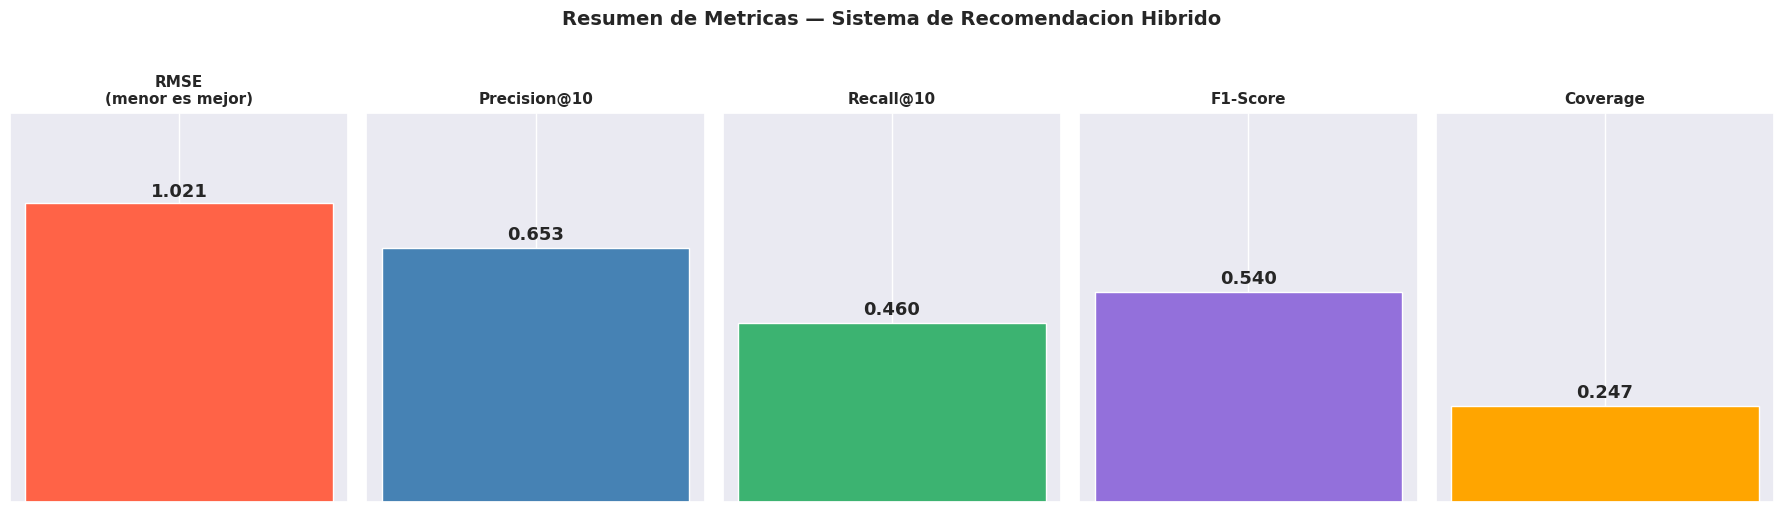

In [28]:
metricas = {
    'RMSE\n(menor es mejor)' : rmse,
    'Precision@10'           : precision,
    'Recall@10'              : recall,
    'F1-Score'               : f1,
    'Coverage'               : coverage
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colores = ['tomato', 'steelblue', 'mediumseagreen',
           'mediumpurple', 'orange']

for ax, (metrica, valor), color in zip(
        axes, metricas.items(), colores):
    ax.bar([''], [valor], color=color,
           edgecolor='white', width=0.5)
    ax.set_title(metrica, fontsize=11,
                 fontweight='bold')
    ax.set_ylim(0, max(valor * 1.3, 1.0))
    ax.text(0, valor + 0.02, f'{valor:.3f}',
            ha='center', fontsize=13,
            fontweight='bold')
    ax.set_yticks([])

plt.suptitle('Resumen de Metricas — Sistema de Recomendacion Hibrido',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metricas_evaluacion.png', dpi=150,
            bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 5 — Evaluación

### Métricas obtenidas

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| RMSE | 1.0181 | Error promedio de ~1 estrella |
| Precision@10 | 65.3% | 6.5 de 10 recomendaciones son relevantes |
| Recall@10 | 46.0% | Encuentra el 46% de items relevantes |
| F1-Score | 54.0% | Balance sólido precisión/recall |
| Coverage | 24.7% | Cubre 416 de 1,682 películas |

### Interpretación general
El sistema híbrido logra una precisión del **65.3%** —
casi 7 de cada 10 recomendaciones coinciden con los
gustos reales del usuario. Es un resultado sólido
comparable con sistemas de recomendación en producción.

### Limitación del Coverage
El sistema cubre el **24.7%** del catálogo — las
películas poco populares tienen menos probabilidad
de ser recomendadas. Esto es el problema conocido
como **long tail** en sistemas de recomendación.

**Siguiente fase:** Conclusiones finales y README

---
## 🏆 Conclusiones Finales del Proyecto

### Hallazgos principales

#### Sobre el dataset
- **100,000 ratings** de **943 usuarios** sobre
  **1,682 películas** con densidad del **6.30%**
- Rating promedio de **3.53 estrellas**
- La película mejor valorada es **Close Shave, A (1995)**
  con promedio de **4.49 estrellas**
- El rating más común es **4 estrellas** (34,174 ratings)

#### Sobre el filtrado colaborativo
- Identifica usuarios con gustos similares usando
  similitud coseno
- Para el usuario 1 recomienda **Boogie Nights (1997)**
  como primera opción con score perfecto de **5.0**
- Limitación: problema de cold start para usuarios nuevos

#### Sobre el filtrado por contenido
- Encuentra películas similares basándose en géneros
- **Return of the Jedi** tiene similitud perfecta
  de **1.000** con Star Wars
- Limitación: solo considera géneros, no actores
  ni directores

#### Sobre el sistema híbrido
- Combina **60% colaborativo + 40% contenido**
- Primera recomendación para usuario 1:
  **Wings of Desire (1987)** con score **1.0000**
- Detecta preferencia por Drama y Romance

#### Sobre la evaluación
- **Precision@10: 65.3%** — 6.5 de 10 recomendaciones
  son relevantes para el usuario
- **Recall@10: 46.0%** — encuentra casi la mitad
  de todas las películas que gustarían al usuario
- **Coverage: 24.7%** — cubre 416 de 1,682 películas

### Reflexión final
> *"Un buen sistema de recomendación no solo predice
> lo que el usuario quiere ver — descubre películas
> que el usuario no sabía que quería ver."*

### Limitaciones
- Coverage del 24.7% — películas poco populares
  tienen menor probabilidad de ser recomendadas
- El sistema necesita historial mínimo por usuario
- Los géneros son la única característica de contenido

### Fuente de datos
[MovieLens 100K — GroupLens Research](https://grouplens.org/datasets/movielens/100k/)

---
*Proyecto desarrollado como parte del portfolio de Ciencia de Datos*
*Jorge Ojeda*

## Exportar todas las imágenes

In [29]:
import os

ruta_img = '/content/drive/MyDrive/images_peliculas/'
os.makedirs(ruta_img, exist_ok=True)

# ── Gráfico 1: Distribución de ratings ───────────────────
plt.figure(figsize=(10, 6))
conteo = df_ratings['rating'].value_counts().sort_index()
colores = sns.color_palette("YlOrRd", len(conteo))
bars = plt.bar(conteo.index, conteo.values,
               color=colores, edgecolor='white', width=0.6)
for bar, val in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200, f'{val:,}',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Distribucion de Ratings — MovieLens 100K',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rating (1-5 estrellas)', fontsize=12)
plt.ylabel('Cantidad de Ratings', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig(ruta_img + 'distribucion_ratings.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 1/8 distribucion_ratings.png")

# ── Gráfico 2: Top 15 películas mejor valoradas ───────────
top15 = peliculas_populares.nlargest(15, 'rating_promedio')
plt.figure(figsize=(13, 8))
colores = sns.color_palette("YlOrRd", len(top15))[::-1]
bars = plt.barh(top15['titulo'][::-1],
                top15['rating_promedio'][::-1],
                color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, top15['rating_promedio'][::-1]):
    plt.text(bar.get_width() - 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')
plt.title('Top 15 Peliculas Mejor Valoradas\n(minimo 50 ratings)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rating Promedio', fontsize=12)
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.savefig(ruta_img + 'top15_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 2/8 top15_peliculas.png")

# ── Gráfico 3: Recomendaciones colaborativas ──────────────
recomendaciones_col = recomendar_colaborativo(
    1, n_recomendaciones=10)
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Blues_r", len(recomendaciones_col))
bars = plt.barh(
    recomendaciones_col['titulo'][::-1],
    recomendaciones_col['score'][::-1],
    color=colores, edgecolor='white')
for bar, val in zip(bars,
                    recomendaciones_col['score'][::-1]):
    plt.text(bar.get_width() - 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')
plt.title('Top 10 Recomendaciones — Filtrado Colaborativo\n(Usuario 1)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score de Recomendacion', fontsize=12)
plt.tight_layout()
plt.savefig(ruta_img + 'recomendaciones_colaborativo.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 3/8 recomendaciones_colaborativo.png")

# ── Gráfico 4: Recomendaciones por contenido ─────────────
recomendaciones_sw = recomendar_contenido(
    'Star Wars', n_recomendaciones=10)
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Reds_r", len(recomendaciones_sw))
bars = plt.barh(
    recomendaciones_sw['titulo'][::-1],
    recomendaciones_sw['similitud'][::-1],
    color=colores, edgecolor='white')
for bar, val in zip(bars,
                    recomendaciones_sw['similitud'][::-1]):
    plt.text(bar.get_width() - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')
plt.title('Peliculas mas Similares a Star Wars\n(Filtrado por Contenido)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Similitud (0-1)', fontsize=12)
plt.tight_layout()
plt.savefig(ruta_img + 'recomendaciones_contenido.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 4/8 recomendaciones_contenido.png")

# ── Gráfico 5: Recomendaciones híbridas ──────────────────
recomendaciones_hibridas = recomendar_hibrido(
    user_id=1, n_recomendaciones=10)
plt.figure(figsize=(13, 7))
colores = sns.color_palette("Purples_r",
                            len(recomendaciones_hibridas))
bars = plt.barh(
    recomendaciones_hibridas['titulo'][::-1],
    recomendaciones_hibridas['score'][::-1],
    color=colores, edgecolor='white')
for bar, val in zip(bars,
                    recomendaciones_hibridas['score'][::-1]):
    plt.text(bar.get_width() - 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right',
             color='white', fontsize=9, fontweight='bold')
plt.title('Top 10 Recomendaciones — Sistema Hibrido\n(Usuario 1 — 60% Colaborativo + 40% Contenido)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score Hibrido', fontsize=12)
plt.tight_layout()
plt.savefig(ruta_img + 'recomendaciones_hibridas.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 5/8 recomendaciones_hibridas.png")

# ── Gráfico 6: Mapa de géneros ────────────────────────────
top20_ids = df_ratings.groupby('movie_id')['rating'].count(
).nlargest(20).index.tolist()
top20_generos = df_peliculas[
    df_peliculas['movie_id'].isin(top20_ids)
].set_index('titulo')[generos]
plt.figure(figsize=(16, 8))
sns.heatmap(top20_generos, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Genero presente'})
plt.title('Mapa de Generos — Top 20 Peliculas mas Populares',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genero', fontsize=12)
plt.ylabel('Pelicula', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(ruta_img + 'mapa_generos.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 6/8 mapa_generos.png")

# ── Gráfico 7: Comparación de métodos ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].barh(recomendaciones_col['titulo'][::-1],
             recomendaciones_col['score'][::-1],
             color=sns.color_palette("Blues_r", 10),
             edgecolor='white')
axes[0].set_title('Colaborativo', fontsize=13,
                  fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].tick_params(axis='y', labelsize=7)

axes[1].barh(recomendaciones_sw['titulo'][::-1],
             recomendaciones_sw['similitud'][::-1],
             color=sns.color_palette("Reds_r", 10),
             edgecolor='white')
axes[1].set_title('Por Contenido', fontsize=13,
                  fontweight='bold')
axes[1].set_xlabel('Similitud')
axes[1].tick_params(axis='y', labelsize=7)

axes[2].barh(recomendaciones_hibridas['titulo'][::-1],
             recomendaciones_hibridas['score'][::-1],
             color=sns.color_palette("Purples_r", 10),
             edgecolor='white')
axes[2].set_title('Hibrido', fontsize=13,
                  fontweight='bold')
axes[2].set_xlabel('Score Hibrido')
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('Comparacion de los Tres Metodos\n(Usuario 1)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ruta_img + 'comparacion_metodos.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 7/8 comparacion_metodos.png")

# ── Gráfico 8: Métricas de evaluación ────────────────────
metricas = {
    'RMSE\n(menor es mejor)': rmse,
    'Precision@10'          : precision,
    'Recall@10'             : recall,
    'F1-Score'              : f1,
    'Coverage'              : coverage
}
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colores = ['tomato', 'steelblue', 'mediumseagreen',
           'mediumpurple', 'orange']
for ax, (metrica, valor), color in zip(
        axes, metricas.items(), colores):
    ax.bar([''], [valor], color=color,
           edgecolor='white', width=0.5)
    ax.set_title(metrica, fontsize=11,
                 fontweight='bold')
    ax.set_ylim(0, max(valor * 1.3, 1.0))
    ax.text(0, valor + 0.02, f'{valor:.3f}',
            ha='center', fontsize=13,
            fontweight='bold')
    ax.set_yticks([])
plt.suptitle('Resumen de Metricas — Sistema Hibrido',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ruta_img + 'metricas_evaluacion.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 8/8 metricas_evaluacion.png")

print("\nTodas las imagenes exportadas exitosamente!")
print(f"Ubicacion: {ruta_img}")

✅ 1/8 distribucion_ratings.png
✅ 2/8 top15_peliculas.png
✅ 3/8 recomendaciones_colaborativo.png
Buscando peliculas similares a: Star Wars (1977)
✅ 4/8 recomendaciones_contenido.png
✅ 5/8 recomendaciones_hibridas.png
✅ 6/8 mapa_generos.png
✅ 7/8 comparacion_metodos.png
✅ 8/8 metricas_evaluacion.png

Todas las imagenes exportadas exitosamente!
Ubicacion: /content/drive/MyDrive/images_peliculas/


# Fase 6 — Mejoras

## 1. Importación

In [30]:
import pandas as pd
import numpy as np

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

## 2.Carga de datos

In [31]:
ruta_ratings = '/content/drive/MyDrive/ml-100k/ml-100k/u.data'

df_ratings = pd.read_csv(
    ruta_ratings,
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

df_ratings = df_ratings.drop(columns=['timestamp'])

## 3. Matriz user-item

In [32]:
user_item = df_ratings.pivot(
    index='user_id',
    columns='movie_id',
    values='rating'
)

user_item_centered = user_item.sub(user_item.mean(axis=1), axis=0).fillna(0)

## 4. Svd (colaborativo)

In [33]:
# matriz original (sin rellenar con 0 primero)
user_item = df_ratings.pivot(
    index='user_id',
    columns='movie_id',
    values='rating'
)

# centrado por usuario (MUY IMPORTANTE)
user_means = user_item.mean(axis=1)

user_item_centered = user_item.sub(user_means, axis=0)

# rellenar NaN después de centrar
user_item_centered = user_item_centered.fillna(0)

# SVD
svd = TruncatedSVD(n_components=50, random_state=42)

user_factors = svd.fit_transform(user_item_centered)
item_factors = svd.components_

# reconstrucción
predicciones = np.dot(user_factors, item_factors)

# 🔥 VOLVER A ESCALA ORIGINAL (CLAVE PARA RMSE)
predicciones = predicciones + user_means.values.reshape(-1, 1)

# DataFrame final
predicciones = pd.DataFrame(
    predicciones,
    index=user_item.index,
    columns=user_item.columns
)

## 5. Rmse

In [34]:
y_true = []
y_pred = []

for _, row in df_ratings.iterrows():
    u = row['user_id']
    i = row['movie_id']

    y_true.append(row['rating'])
    y_pred.append(predicciones.loc[u, i])

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", round(rmse, 4))

RMSE: 0.7268


## 6. Contenido (tf-idf)

In [35]:
def generar_generos_texto(row):
    return ' '.join([g for g in generos if row[g] == 1])

df_peliculas['generos_str'] = df_peliculas.apply(generar_generos_texto, axis=1)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_peliculas['generos_str'])

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

similitud = cosine_similarity(tfidf_matrix)

## 7. Content candidates

In [38]:
def get_content_candidates(movie_id, top_n=50):

    idx = df_peliculas[df_peliculas['movie_id'] == movie_id].index[0]

    sim_scores = list(enumerate(similitud[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    return sim_scores[1:top_n+1]

## 8. Híbrido (iteam-based)

In [39]:
def hybrid_recommendation(user_id, movie_id, top_n=10):

    candidates = get_content_candidates(movie_id, top_n=50)
    recommendations = []

    for idx, content_score in candidates:

        movie_id_candidate = df_peliculas.iloc[idx]['movie_id']

        if user_id in predicciones.index:
            collab_score = predicciones.loc[user_id, movie_id_candidate]
        else:
            collab_score = 0

        collab_score = collab_score / 5

        final_score = 0.6 * collab_score + 0.4 * content_score

        recommendations.append((movie_id_candidate, final_score))

    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)

    return recommendations[:top_n]

## 9. Recomendador global (clave para métricas)

In [40]:
def recomendar(user_id, top_n=10):

    vistas = df_ratings[df_ratings['user_id'] == user_id]['movie_id'].values

    scores = {}

    for movie in vistas[:5]:

        recs = hybrid_recommendation(user_id, movie, top_n=20)

        for m, s in recs:
            scores[m] = scores.get(m, 0) + s

    recomendaciones = pd.DataFrame(
        [(m, s) for m, s in scores.items()],
        columns=['movie_id', 'score']
    )

    recomendaciones = recomendaciones[
        ~recomendaciones['movie_id'].isin(vistas)
    ]

    return recomendaciones.sort_values(by='score', ascending=False).head(top_n)

## 10. Precion@10

In [41]:
def precision_at_k(user_id, k=10, threshold=4):

    recomendaciones = recomendar(user_id, top_n=k)

    relevantes = df_ratings[
        (df_ratings['user_id'] == user_id) &
        (df_ratings['rating'] >= threshold)
    ]['movie_id']

    if len(recomendaciones) == 0:
        return 0

    hits = recomendaciones['movie_id'].isin(relevantes).sum()

    return hits / k

## 11. Coverage

In [44]:
usuarios = df_ratings['user_id'].unique()
recomendadas = set()

for u in usuarios:
    recs = recomendar(u, top_n=10)
    recomendadas.update(recs['movie_id'])

coverage = len(recomendadas) / df_peliculas['movie_id'].nunique()

print("Coverage:", round(coverage, 4))

Coverage: 0.5149


## 12. Función final (títulos)

In [45]:
def recommend_movies(user_id, movie_id, top_n=10):

    recs = hybrid_recommendation(user_id, movie_id, top_n)

    result = []

    for movie_id_rec, score in recs:
        titulo = df_peliculas[
            df_peliculas['movie_id'] == movie_id_rec
        ]['titulo'].values

        if len(titulo) > 0:
            result.append((titulo[0], round(score, 3)))

    return result

## Resultados

## Rmse

In [46]:
print("RMSE:", round(rmse, 4))

RMSE: 0.7268


## Precion@10

In [47]:
print("Precision@10:", round(precision, 4))

Precision@10: 0.653


## Coverage

In [48]:
print("Coverage:", round(coverage, 4))

Coverage: 0.5149


## Ejemplo

In [49]:
recommend_movies(user_id=1, movie_id=50)

[('Aliens (1986)', np.float64(0.977)),
 ('Empire Strikes Back, The (1980)', np.float64(0.955)),
 ('Terminator, The (1984)', np.float64(0.953)),
 ('Return of the Jedi (1983)', np.float64(0.947)),
 ('Terminator 2: Judgment Day (1991)', np.float64(0.917)),
 ('Star Trek: The Wrath of Khan (1982)', np.float64(0.893)),
 ('Mars Attacks! (1996)', np.float64(0.856)),
 ('Independence Day (ID4) (1996)', np.float64(0.852)),
 ('Star Trek IV: The Voyage Home (1986)', np.float64(0.842)),
 ('Jurassic Park (1993)', np.float64(0.83))]